In [1]:
import numpy as np
from matplotlib import pyplot as plt
import gillespy2

In [31]:
def opto_input(t):
    out = 50 if t<100 else 0
    return str(out)

def CcaSR_1layer(init_con, params,fun, t_max,parameter_values=None):    

    model = gillespy2.Model(name='CcaSR')
    
    alpha , k , n , tau_delay , h1 , h2 , c2,delta = params
    

    alpha_g = gillespy2.Parameter(name='alpha', expression=alpha)
    delta_g = gillespy2.Parameter(name='delta', expression=delta)
    c2_g = gillespy2.Parameter(name='c2', expression=c2)
    k_g = gillespy2.Parameter(name='k', expression=k)
    n_g = gillespy2.Parameter(name='n', expression=n)
    tau_delay_g = gillespy2.Parameter(name='tau_delay', expression=tau_delay)
    h1_g = gillespy2.Parameter(name='h1', expression=h1)
    h2_g = gillespy2.Parameter(name='h2', expression=h2)
    
    model.add_parameter([alpha_g,delta_g,c2_g,k_g,n_g,tau_delay_g,h1_g,h2_g])

    
    U = gillespy2.Species(name='U', initial_value=1,mode='discrete')
    H = gillespy2.Species(name='H', initial_value=init_con[0])
    E = gillespy2.Species(name='E',   initial_value=round(np.random.poisson(h1/h2)))
    F = gillespy2.Species(name='F',   initial_value=init_con[2])
    model.add_species([U,H,E,F])

    # The list of reactants and products for a Reaction object are each a
    # Python dictionary in which the dictionary keys are Species objects
    # and the values are stoichiometries of the species in the reaction.
    H_c = gillespy2.Reaction(name="H_creation", propensity_function= 'U', reactants={}, products={H:1})
    H_d = gillespy2.Reaction(name="H_dissociation", propensity_function='c2*H', reactants={H:1}, products={})
    E_c = gillespy2.Reaction(name="E_creation", propensity_function= 'h1', reactants={}, products={E:1})
    E_d = gillespy2.Reaction(name="E_dissociation", propensity_function='h2*E', reactants={E:1}, products={})
    F_c = gillespy2.Reaction(name="F_creation", propensity_function= 'alpha*E*(pow(c2*H,n)/(k+pow(c2*H,n)))', reactants={}, products={F:1})
    F_d = gillespy2.Reaction(name="F_dissociation", propensity_function='delta*F', reactants={F:1}, products={})
    
    model.add_reaction([H_c,H_d,E_c,E_d,F_c,F_d])

    # Set the timespan for the simulation.
    tspan = gillespy2.TimeSpan.linspace(t=t_max, num_points=101)
    model.timespan(tspan)
    return model


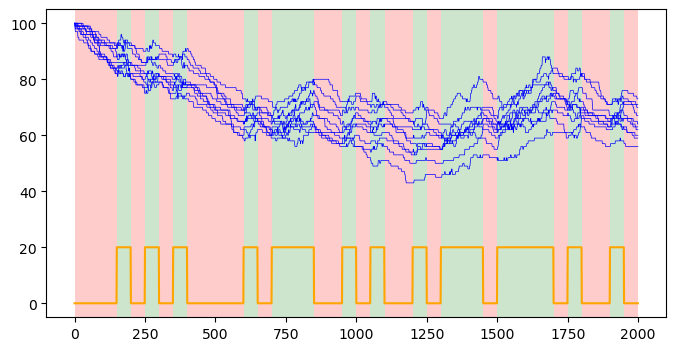

In [ ]:
class Simple(gillespy2.Model):
    def __init__(self,params,t_max,stim_vec):
        super().__init__(name='Simple_rxn')
        self.params = params
        self.t_max = t_max
        self.stim_vec = stim_vec
        self.reporter_species = None
        self.input_species = None
    
    def init_rxn(self):
        delta = self.params

        delta_g = gillespy2.Parameter(name='delta', expression=delta)
        
        self.add_parameter([delta_g])

        
        A = gillespy2.Species(name='A', initial_value=100,mode='discrete')
        B = gillespy2.Species(name='B', initial_value=0,mode='discrete')
        self.reporter_species = 'A'
        self.input_species = 'B'
        self.add_species([A,B])

        # The list of reactants and products for a Reaction object are each a
        # Python dictionary in which the dictionary keys are Species objects
        # and the values are stoichiometries of the species in the reaction.
        A_d = gillespy2.Reaction(name="A_degradation", propensity_function= 'delta*A', reactants={A:1}, products={})
        A_c = gillespy2.Reaction(name="A_creation", propensity_function= 'B', reactants={}, products={A:1})
        self.add_reaction([A_d,A_c])
    
    def update_rxn(self):
        for i,stim in enumerate(self.stim_vec):
            ea = gillespy2.EventAssignment(variable=self.input_species, expression=stim)
            et = gillespy2.EventTrigger(expression='1',initial_value=False)
            e = gillespy2.Event(name=f'event{i}', trigger=et, assignments=[ea],delay=f'{5*i}')
            self.add_event([e])
        

    def run_rxn(self):
        tspan = gillespy2.TimeSpan.linspace(t=self.t_max, num_points=int(self.t_max*10))
        self.timespan(tspan)
        self.init_rxn()
        self.update_rxn()
        results = self.run(number_of_trajectories=10,algorithm="Tau-Hybrid")
        return results

stim_vec = np.random.choice(2,40)
test = Simple(0.01,200,stim_vec)
results = test.run_rxn()

fig, ax = plt.subplots(figsize=(8, 4))
for i, val in enumerate(stim_vec):
    x_start = i * 50
    x_end = x_start + 50
    color = 'green' if val == 1 else 'red'
    ax.axvspan(x_start, x_end, facecolor=color, alpha=0.2)

for i in range(10):
    ax.plot((results[i]['A']),color='b',linewidth = 0.5)
ax.plot(np.array(results[0]['B'])*20,color = 'orange')
plt.show()        


In [196]:
class CcaSR(gillespy2.Model):
    def __init__(self,params,t_max,sampling=10):
        super().__init__(name='CcaSR')
        self.params = params
        self.t_max = t_max
        self.sampling = sampling
        self.reporter_species = None
        self.input_species = None
    
    def init_rxn(self):
        alpha , k , n , tau_delay , h1 , h2 , c2,delta = self.params

        alpha_g = gillespy2.Parameter(name='alpha', expression=alpha)
        delta_g = gillespy2.Parameter(name='delta', expression=delta)
        c2_g = gillespy2.Parameter(name='c2', expression=c2)
        k_g = gillespy2.Parameter(name='k', expression=k)
        n_g = gillespy2.Parameter(name='n', expression=n)
        tau_delay_g = gillespy2.Parameter(name='tau_delay', expression=tau_delay)
        h1_g = gillespy2.Parameter(name='h1', expression=h1)
        h2_g = gillespy2.Parameter(name='h2', expression=h2)
        
        self.add_parameter([alpha_g,delta_g,c2_g,k_g,n_g,tau_delay_g,h1_g,h2_g])

        
        U = gillespy2.Species(name='U', initial_value=0,mode='discrete')
        H = gillespy2.Species(name='H', initial_value=0,mode='discrete')
        E = gillespy2.Species(name='E',   initial_value=round(np.random.poisson(h1/h2)),mode='discrete')
        F = gillespy2.Species(name='F',   initial_value=0,mode='discrete')
        self.reporter_species = 'F'
        self.input_species = 'U'
        self.add_species([U,H,E,F])

        # The list of reactants and products for a Reaction object are each a
        # Python dictionary in which the dictionary keys are Species objects
        # and the values are stoichiometries of the species in the reaction.
        H_c = gillespy2.Reaction(name="H_creation", propensity_function= 'U', reactants={}, products={H:1})
        H_d = gillespy2.Reaction(name="H_dissociation", propensity_function='c2*H', reactants={H:1}, products={})
        E_c = gillespy2.Reaction(name="E_creation", propensity_function= 'h1', reactants={}, products={E:1})
        E_d = gillespy2.Reaction(name="E_dissociation", propensity_function='h2*E', reactants={E:1}, products={})
        F_c = gillespy2.Reaction(name="F_creation", propensity_function= 'alpha*E*(pow(c2*H,n)/(k+pow(c2*H,n)))', reactants={}, products={F:1})
        F_d = gillespy2.Reaction(name="F_dissociation", propensity_function='delta*F', reactants={F:1}, products={})
    
        self.add_reaction([H_c,H_d,E_c,E_d,F_c,F_d])
    
    def update_rxn(self,stim_vec):
        for i,stim in enumerate(stim_vec):
            ea = gillespy2.EventAssignment(variable=self.input_species, expression=stim)
            et = gillespy2.EventTrigger(expression='1',initial_value=False)
            e = gillespy2.Event(name=f'event{i}', trigger=et, assignments=[ea],delay=f'{(5*i)+self.params[3]}')
            self.add_event([e])
    
    def get_updates(self,updates):
        self.delete_all_species()
        for name,value in updates.items():
            self.add_species(gillespy2.Species(name = name, initial_value= value, mode = 'discrete'))    

    def run_rxn(self,stim_vec):
        tot_results = []
        tspan = gillespy2.TimeSpan.linspace(t=self.t_max, num_points=int(self.t_max*self.sampling))
        self.timespan(tspan)
        self.init_rxn()
        for stim in stim_vec:
            self.update_rxn(stim)
            results = self.run(number_of_trajectories=1,algorithm="Tau-Hybrid")
            tot_results.append(results)
            self.delete_all_events()
            updates = {}
            for name in self.get_all_species().keys():
                updates[name] = results[name][-1]
            self.get_updates(updates)
        return tot_results



In [205]:
def rep_stim_maker(num_repeat,total_time):
    num_reps = int(np.floor(total_time/num_repeat))
    ons = np.repeat(1,num_reps)
    offs = np.repeat(0,num_reps)
    tile = np.hstack((ons,offs))
    stim_vec = np.tile(tile,int(num_repeat))
    stim_vec = stim_vec[:total_time]
    return stim_vec

num_steps = 200
ons = np.repeat(1,50)
offs = np.repeat(0,50)
#stim_vec = np.random.choice(2,num_steps, p =[0.75,0.25])
stim_vec2 = rep_stim_maker(6,80)
#stim_vec2 = np.hstack((stim_vec,np.zeros(100),np.ones(50),np.zeros(50)))

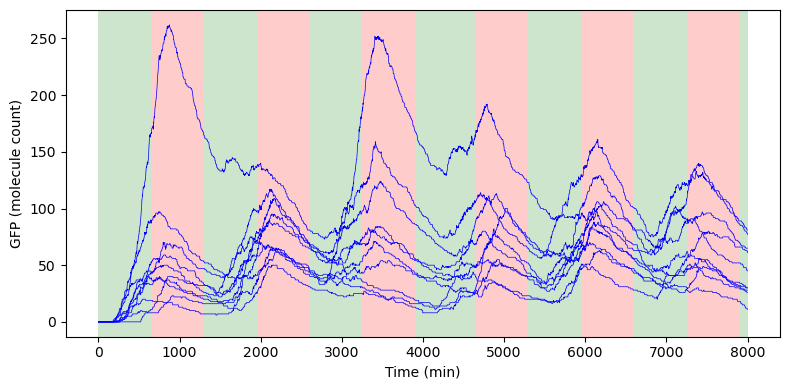

In [206]:
delta = 0.01
alpha = 1
k = 0.4851
h1 = 2.3435*0.0303
h2 = 0.0303
tau_delay = 12
n=3.6
c2 = 0.0631
params = [alpha , k , n , tau_delay , h1 , h2 ,c2 , delta]
#stim_vec = np.random.choice(2,80)
stim_vec =[stim_vec2,stim_vec2]
t_max = 400
sampling = 10
mega_res = []
for i in range(10):
    test = CcaSR(params,t_max,sampling)
    results = test.run_rxn(stim_vec)
    mega_res.append(results)

fig, ax = plt.subplots(figsize=(8, 4))
for j in range(len(stim_vec)):
    for i, val in enumerate(stim_vec[j]):
        x_start = j*t_max*sampling + i * 5*sampling
        x_end = x_start + 5*sampling
        color = 'green' if val == 1 else 'red'
        ax.axvspan(x_start, x_end, facecolor=color, alpha=0.2)
for k in range(len(mega_res)):
    results = mega_res[k]
    for i in range(len(results)):
        ax.plot(np.arange(t_max*i*sampling,t_max*(i+1)*sampling),(results[i]['F']),color='b',linewidth = 0.5)

#ax.plot(np.array(results[i]['U'])*20,color='orange',linewidth = 1)
#ax.set_xticks(np.arange(0,4500,500))
#ax.set_xticklabels(np.arange(0,450,50))
ax.set_xlabel('Time (min)')
ax.set_ylabel('GFP (molecule count)')
plt.tight_layout()
plt.show()    

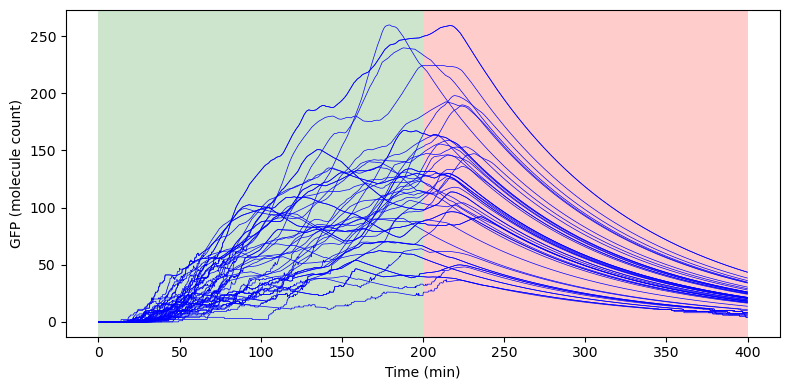

In [147]:
ons = np.ones(40)
offs = np.zeros(40)
stim_vec = np.hstack((ons,offs))
test = CcaSR(params,400,stim_vec)
results = test.run_rxn()

fig, ax = plt.subplots(figsize=(8, 4))
for i, val in enumerate(stim_vec):
    x_start = i * 50
    x_end = x_start + 50
    color = 'green' if val == 1 else 'red'
    ax.axvspan(x_start, x_end, facecolor=color, alpha=0.2)

for i in np.random.choice(100,50):
    ax.plot((results[i]['F']),color='b',linewidth = 0.5)
#ax.plot(np.array(results[i]['U'])*20,color='orange',linewidth = 1)
ax.set_xticks(np.arange(0,4500,500))
ax.set_xticklabels(np.arange(0,450,50))
ax.set_xlabel('Time (min)')
ax.set_ylabel('GFP (molecule count)')
plt.tight_layout()
plt.show()    